In [38]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage import filters, color
from skimage.feature import graycomatrix, graycoprops
from mpl_toolkits.mplot3d import Axes3D


In [39]:
image = Image.open("C://Users//gajje//Downloads//archive (1) (1)//Testing//glioma//Te-glTr_0001.jpg")   #C:\Users\gajje\Downloads\archive (1) (1)\Training
# image_array = np.array(image)

 it's important to convert them to grayscale. This is because texture analysis and edge detection generally work better on single-channel images where intensity alone matters. Grayscale images have pixel intensities ranging from 0 (black) to 255 (white).
 
 Formula: If the image is RGB (3 channels), the grayscale conversion is typically done using a weighted sum of the RGB values:
Gray=0.2989×R+0.5870×G+0.1140×B
Gray=0.2989×R+0.5870×G+0.1140×B This formula accounts for human perception of brightness, which is more sensitive to green than red and blue.

In [40]:
image_gray = image.convert('L')  # 'L' mode is for grayscale
image_array = np.array(image_gray)

Normalization scales the pixel values between 0 and 1. This is important because different MRI scans may have different intensity ranges, and we want to standardize them for comparison.
image_normalized=max(image_array)−min(image_array)image_array−min(image_array)​
  

In [41]:
image_normalized = (image_array - np.min(image_array)) / (np.max(image_array) - np.min(image_array))

This is the average intensity of the grayscale image and gives us an overall sense of how "bright" or "dark" the image is. Tumor regions may have different average intensities compared to non-tumor regions due to the different tissue types.

This measures the variability or spread of the pixel intensities in the image. High variability might suggest the presence of different tissue types, including abnormal regions like tumors.

In [42]:
mean_intensity = np.mean(image_normalized)
std_intensity = np.std(image_normalized)

This measures the variability or spread of the pixel intensities in the image. High variability might suggest the presence of different tissue types, including abnormal regions like tumors.

In [43]:
edges = filters.sobel(image_normalized)

The Gray Level Co-occurrence Matrix (GLCM) captures texture information by analyzing how frequently pairs of pixel intensities (gray levels) occur together at a given distance and angle. This is useful for detecting patterns in the image that might indicate tumors. We compute several statistical properties from the GLCM:
Contrast=i,j∑​(i−j)2⋅P(i,j)

In [44]:
glcm = graycomatrix((image_normalized * 255).astype(np.uint8), 
                    distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256, 
                    symmetric=True, normed=True)
contrast = graycoprops(glcm, 'contrast')[0, 0]
correlation = graycoprops(glcm, 'correlation')[0, 0]
energy = graycoprops(glcm, 'energy')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

Extract GLCM Properties:
**
    This block extracts various statistical measures from the GLCM:
        Contrast: Measures the local variations in the gray level. High contrast may indicate tumor presence.
        Correlation: Describes the joint probability of the pixel pairs. It measures how correlated a pixel is to its neighbor over the whole image.
        Energy: Also known as Angular Second Moment, it indicates textural uniformity. High energy suggests low texture complexity.
        Homogeneity: Measures the closeness of the distribution of elements in GLCM to the GLCM diagonal. Higher values indicate more uniform textures, which may help differentiate between tumor and normal tissue**.

In [45]:
def tumor_likelihood(image, weights):
    # Intensity features
    mean_intensity = np.mean(image)
    std_intensity = np.std(image)
    
    # Edge features
    edges = filters.sobel(image)
    
    # Texture features (GLCM)
    glcm = graycomatrix((image * 255).astype(np.uint8), distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], 
                        levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    
    # Tumor likelihood score calculation based on intensity, edges, and texture
    T = (weights[0] * (std_intensity / mean_intensity) +
         weights[1] * np.mean(edges) +
         weights[2] * contrast +
         weights[3] * energy)
    
    return T

Tumor Likelihood Function:

**    This function calculates a tumor likelihood score TT based on various image features using a weighted sum.
    It considers the mean intensity, standard deviation, edge strength, contrast, and energy, applying weights to each feature to reflect their importance.
    The result TT will be used for classification later.**

In [46]:
weights = [0.3, 0.3, 0.2, 0.2]

In [47]:
tumor_score = tumor_likelihood(image_normalized, weights)

**Assign Weights and Calculate Tumor Score:

**    The weights assigned to each feature (based on their relative importance) are used to compute the tumor score. These weights can be fine-tuned through empirical validation to optimize the classification performance.****

In [48]:
threshold = 0.5

# Classify the MRI scan based on tumor score
if tumor_score >= threshold:
    classification = "Tumor"
else:
    classification = "Not Tumor"
    
print(f"Tumor Likelihood Score: {tumor_score:.4f}")
print(f"Classification: {classification}")

Tumor Likelihood Score: 5.3907
Classification: Tumor


In [49]:
plt.figure(figsize=(15, 15))

<Figure size 1500x1500 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

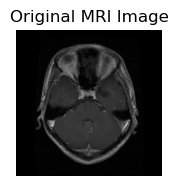

In [50]:
plt.subplot(131)
plt.imshow(image_normalized, cmap='gray')
plt.title('Original MRI Image')
plt.axis('off')


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

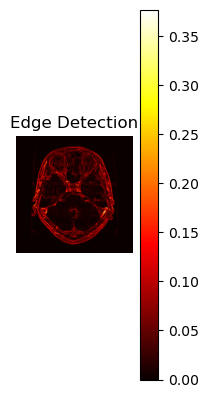

In [51]:
plt.subplot(132)
plt.imshow(edges, cmap='hot')
plt.title('Edge Detection')
plt.colorbar()
plt.axis('off')


Text(0, 0.5, 'Frequency')

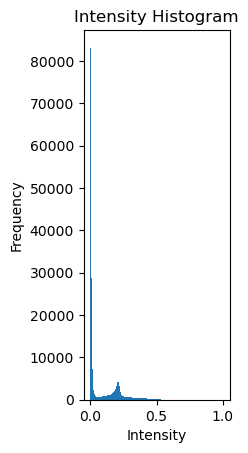

In [52]:
# Intensity Histogram
plt.subplot(133)
plt.hist(image_normalized.ravel(), bins=256)
plt.title('Intensity Histogram')
plt.xlabel('Intensity')
plt.ylabel('Frequency')

In [53]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

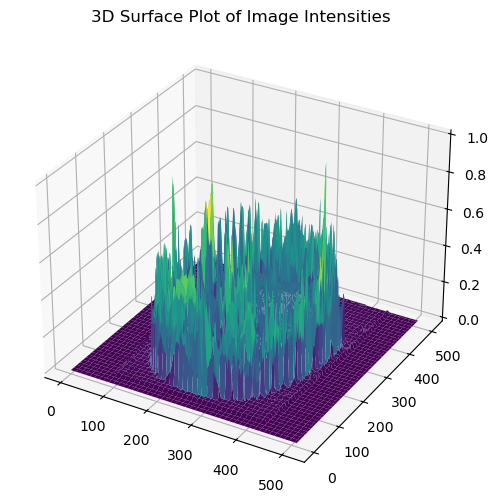

In [54]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
x, y = np.meshgrid(range(image_normalized.shape[1]), range(image_normalized.shape[0]))
ax.plot_surface(x, y, image_normalized, cmap='viridis')
plt.title('3D Surface Plot of Image Intensities')
plt.show()